# Raport 2 - model training

## Train test split

own implementation with stratification

Stratifying a dataset means dividing it into distinct subgroups (strata) based on shared characteristics, like age or class label. This ensures that when the dataset is split for tasks like machine learning model training, each subset (training, validation, and test sets) maintains the same proportional representation of the strata as the original dataset.

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

In [2]:
def stratified_train_val_test_split(X, y, test_size=0.2, val_size=0.1, random_state=42):
    if hasattr(X, 'values'):
        X = X.values
    if hasattr(y, 'values'):
        y = y.values

    classes = np.unique(y)
    train_indices = []
    val_indices = []
    test_indices = []

    rng = np.random.RandomState(random_state)

    for cls in classes:
        cls_idx = np.where(y == cls)[0].tolist()
        rng.shuffle(cls_idx)
        n = len(cls_idx)
        n_test = int(round(n * test_size))
        n_val = int(round(n * val_size))

        test_idx = cls_idx[:n_test]
        val_idx = cls_idx[n_test:n_test + n_val]
        train_idx = cls_idx[n_test + n_val:]

        train_indices.extend(train_idx)
        val_indices.extend(val_idx)
        test_indices.extend(test_idx)

    # Convert to numpy arrays for indexing
    train_indices = np.array(train_indices, dtype=int)
    val_indices = np.array(val_indices, dtype=int)
    test_indices = np.array(test_indices, dtype=int)

    X_train = X[train_indices]
    X_val = X[val_indices]
    X_test = X[test_indices]
    y_train = y[train_indices]
    y_val = y[val_indices]
    y_test = y[test_indices]

    return X_train, X_val, X_test, y_train, y_val, y_test

df = pd.read_csv('alzheimers_disease_data.csv')
target = 'Diagnosis'
X = df.drop(columns=['PatientID', 'DoctorInCharge', target])
y = df[target].astype(int)

X_train, X_val, X_test, y_train, y_val, y_test = stratified_train_val_test_split(
    X, y, test_size=0.2, val_size=0.1, random_state=42
)


### Test the split balance 

In [3]:
print("\nDataset distribution:")
unique, counts = np.unique(y, return_counts=True)
total = len(y)
for cls, count in zip(unique, counts):
    percent = (count / total) * 100
    print(f"Class {cls}: {count} samples ({percent:.2f}%)")

unique_train, counts_train = np.unique(y_train, return_counts=True)
total_train = len(y_train)
print("\nTraining set distribution:")
for cls, count in zip(unique_train, counts_train):
    percent = (count / total_train) * 100
    print(f"Class {cls}: {count} samples ({percent:.2f}%)")

unique_val, counts_val = np.unique(y_val, return_counts=True)
total_val = len(y_val)
print("\nValidation set distribution:")
for cls, count in zip(unique_val, counts_val):
    percent = (count / total_val) * 100
    print(f"Class {cls}: {count} samples ({percent:.2f}%)")

unique_test, counts_test = np.unique(y_test, return_counts=True)
total_test = len(y_test)
print("\nTest set distribution:")
for cls, count in zip(unique_test, counts_test):
    percent = (count / total_test) * 100
    print(f"Class {cls}: {count} samples ({percent:.2f}%)")



Dataset distribution:
Class 0: 1389 samples (64.63%)
Class 1: 760 samples (35.37%)

Training set distribution:
Class 0: 972 samples (64.63%)
Class 1: 532 samples (35.37%)

Validation set distribution:
Class 0: 139 samples (64.65%)
Class 1: 76 samples (35.35%)

Test set distribution:
Class 0: 278 samples (64.65%)
Class 1: 152 samples (35.35%)


As you can see, each split's distribution of classes is verys similar to the dataset's distribution. 
That is how we know stratification is implemented correctly.

Restore the preprocessed datasets from files, which are produced by: 
- `prepare_base.py` prepared the baseline dataset
- `prepare_datasets.py` first removed 10% of the data, then performed 4 imputation techniques

Each dataset was then scaled using z_score or min_max technique.

In [5]:
import os

restore_folder = "scaled_data"
restored_datasets = {}

for filename in os.listdir(restore_folder):
    if filename.endswith(".csv"):
        key = filename.replace(".csv", "")
        df = pd.read_csv(f"{restore_folder}/{filename}")
        restored_datasets[key] = df

print("\nRestored datasets keys:\n")
for k, _ in restored_datasets.items():
    print( k)

base_dataset = pd.read_csv('scaled_data/base.csv')
scaled_datasets = restored_datasets | {'base': base_dataset}


Restored datasets keys:

base
constant_minmax
constant_zscore
interpolated_minmax
interpolated_zscore
knn_minmax
knn_zscore
pycaret_mean_minmax
pycaret_mean_zscore


## Define the Metrics

Metrics for model quality assessment, implemented manually.

In [ ]:
def accuracy_manual(y_true, y_pred):
    """
    (accuracy) - procent poprawnych predykcji.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    correct = np.sum(y_true == y_pred)
    total = len(y_true)
    return correct / total if total > 0 else 0.0


def precision_manual(y_true, y_pred, average='weighted'):
    """
    (precision) - stosunek prawdziwie pozytywnych do wszystkich pozytywnych predykcji.
    Wspiera average='weighted' dla problemu wieloklasowego.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    classes = np.unique(np.concatenate([y_true, y_pred]))
    
    if average == 'weighted':
        precisions = []
        weights = []
        
        for cls in classes:
            tp = np.sum((y_true == cls) & (y_pred == cls))
            fp = np.sum((y_true != cls) & (y_pred == cls))
            
            if (tp + fp) > 0:
                precision = tp / (tp + fp)
            else:
                precision = 0.0
            
            precisions.append(precision)
            weights.append(np.sum(y_true == cls))
        
        total_weight = sum(weights)
        if total_weight > 0:
            weighted_precision = sum(p * w for p, w in zip(precisions, weights)) / total_weight
            return weighted_precision
        else:
            return 0.0
    else:
        raise NotImplementedError("Only 'weighted' average is implemented")


def recall_manual(y_true, y_pred, average='weighted'):
    """
    (recall) - stosunek prawdziwie pozytywnych do wszystkich rzeczywiście pozytywnych.
    Wspiera average='weighted' dla problemu wieloklasowego.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    classes = np.unique(np.concatenate([y_true, y_pred]))
    
    if average == 'weighted':
        recalls = []
        weights = []
        
        for cls in classes:
            tp = np.sum((y_true == cls) & (y_pred == cls))
            fn = np.sum((y_true == cls) & (y_pred != cls))
            
            if (tp + fn) > 0:
                recall = tp / (tp + fn)
            else:
                recall = 0.0
            
            recalls.append(recall)
            weights.append(np.sum(y_true == cls))
        
        total_weight = sum(weights)
        if total_weight > 0:
            weighted_recall = sum(r * w for r, w in zip(recalls, weights)) / total_weight
            return weighted_recall
        else:
            return 0.0
    else:
        raise NotImplementedError("Only 'weighted' average is implemented")


def f1_score_manual(y_true, y_pred, average='weighted'):
    """
    F1-score - harmoniczna średnia precision i recall.
    """
    precision = precision_manual(y_true, y_pred, average=average)
    recall = recall_manual(y_true, y_pred, average=average)
    
    if (precision + recall) > 0:
        f1 = 2 * (precision * recall) / (precision + recall)
        return f1
    else:
        return 0.0

## Define the models

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB
from sklearn.neighbors import NearestCentroid, KNeighborsClassifier 
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

sklearn_models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(random_state=42),
    'NearestCentroid': NearestCentroid(),
    'KNeighborsClassifier': KNeighborsClassifier(),
    'BernoulliNB': BernoulliNB(),
}

external_models = {
    'XGBoost': XGBClassifier(random_state=42),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=0),
}

# Combine all models into a single dictionary
models = sklearn_models | external_models
models

{'Logistic Regression': LogisticRegression(random_state=42),
 'Random Forest': RandomForestClassifier(random_state=42),
 'SVM': SVC(random_state=42),
 'NearestCentroid': NearestCentroid(),
 'KNeighborsClassifier': KNeighborsClassifier(),
 'BernoulliNB': BernoulliNB(),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=None, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=None,
     

## Training

In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# Train models for each scaled dataset
all_results = {}

for dataset_name, df in scaled_datasets.items():
    print(f"\n{'='*70}")
    print(f"Processing dataset: {dataset_name}")
    print(f"{'='*70}")
    
    target = 'Diagnosis'
    X = df.drop(columns=[target])
    y = df[target].astype(int)
    
    X_train, X_val, X_test, y_train, y_val, y_test = stratified_train_val_test_split(
        X, y, test_size=0.2, val_size=0.1, random_state=42
    )
    
    dataset_results = {}
    
    # Train and evaluate each model
    for model_name, model in models.items():
        print(f"\nTraining {model_name}...")
        
        model.fit(X_train, y_train)
        
        # Predictions on all sets
        y_train_pred = model.predict(X_train)
        y_val_pred = model.predict(X_val)
        y_test_pred = model.predict(X_test)
        
        # Metrics
        train_acc = accuracy_score(y_train, y_train_pred)
        val_acc = accuracy_score(y_val, y_val_pred)
        test_acc = accuracy_score(y_test, y_test_pred)
        test_precision = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
        test_recall = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
        test_f1 = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)
        
        dataset_results[model_name] = {
            'model': model,
            'train_acc': train_acc,
            'val_acc': val_acc,
            'test_acc': test_acc,
            'precision': test_precision,
            'recall': test_recall,
            'f1': test_f1,
            'y_test_pred': y_test_pred
        }
        
        print(f"  Train Accuracy: {train_acc:.4f}")
        print(f"  Validation Accuracy: {val_acc:.4f}")
    
    all_results[dataset_name] = dataset_results


Processing dataset: base

Training Logistic Regression...
  Train Accuracy: 0.8471
  Validation Accuracy: 0.8558

Training Random Forest...
  Train Accuracy: 1.0000
  Validation Accuracy: 0.9442

Training SVM...
  Train Accuracy: 0.9322
  Validation Accuracy: 0.8512

Training NearestCentroid...
  Train Accuracy: 0.7606
  Validation Accuracy: 0.8047

Training KNeighborsClassifier...
  Train Accuracy: 0.8457
  Validation Accuracy: 0.7628

Training BernoulliNB...
  Train Accuracy: 0.8624
  Validation Accuracy: 0.8884

Training XGBoost...
  Train Accuracy: 1.0000
  Validation Accuracy: 0.9721

Training CatBoost...
  Train Accuracy: 0.9860
  Validation Accuracy: 0.9814

Processing dataset: constant_minmax

Training Logistic Regression...
  Train Accuracy: 0.7753
  Validation Accuracy: 0.7767

Training Random Forest...
  Train Accuracy: 1.0000
  Validation Accuracy: 0.9023

Training SVM...
  Train Accuracy: 0.8604
  Validation Accuracy: 0.7767

Training NearestCentroid...
  Train Accuracy: 

### Comparing own implementations vs sklearn metrics

for first dataset and first model

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

first_dataset = list(all_results.keys())[0]
first_model = list(all_results[first_dataset].keys())[0]
result = all_results[first_dataset][first_model]

print("Porównanie ręcznych implementacji metryk z sklearn:")
print("="*70)
print(f"Dataset: {first_dataset}, Model: {first_model}\n")
print("Metryka              | Sklearn    | Manual     | Różnica")
print("-" * 70)

acc_sklearn = accuracy_score(result['y_test'], result['y_test_pred'])
print(f"Accuracy             | {acc_sklearn:.6f} | {result['test_acc']:.6f} | {abs(acc_sklearn - result['test_acc']):.6f}")

prec_sklearn = precision_score(result['y_test'], result['y_test_pred'], average='weighted', zero_division=0)
print(f"Precision (weighted) | {prec_sklearn:.6f} | {result['precision']:.6f} | {abs(prec_sklearn - result['precision']):.6f}")

rec_sklearn = recall_score(result['y_test'], result['y_test_pred'], average='weighted', zero_division=0)
print(f"Recall (weighted)    | {rec_sklearn:.6f} | {result['recall']:.6f} | {abs(rec_sklearn - result['recall']):.6f}")

f1_sklearn = f1_score(result['y_test'], result['y_test_pred'], average='weighted', zero_division=0)
print(f"F1-score (weighted)  | {f1_sklearn:.6f} | {result['f1']:.6f} | {abs(f1_sklearn - result['f1']):.6f}")

print("\nWszystkie metryki zostały poprawnie zaimplementowane!" if 
      all([abs(acc_sklearn - result['test_acc']) < 1e-6,
           abs(prec_sklearn - result['precision']) < 1e-6,
           abs(rec_sklearn - result['recall']) < 1e-6,
           abs(f1_sklearn - result['f1']) < 1e-6])
      else "\nWykryto różnice w implementacjach!")

Porównanie ręcznych implementacji metryk z sklearn:
Dataset: base, Model: Logistic Regression

Metryka              | Sklearn    | Manual     | Różnica
----------------------------------------------------------------------
Accuracy             | 0.827907 | 0.827907 | 0.000000
Precision (weighted) | 0.825866 | 0.825866 | 0.000000
Recall (weighted)    | 0.827907 | 0.827907 | 0.000000
F1-score (weighted)  | 0.826189 | 0.826885 | 0.000696

Wykryto różnice w implementacjach!


### Compare model results

using our metric of course, on each dataset

In [8]:
print(f"\n{'='*70}")
print("FINAL SUMMARY - All Datasets and Models")
print(f"{'='*70}")
for dataset_name, dataset_results in all_results.items():
    print(f"\n{dataset_name}:")
    for model_name, metrics in dataset_results.items():
        print(f"{model_name:>20}:  Accuracy={metrics['test_acc']:.4f}, F1={metrics['f1']:.4f}")


FINAL SUMMARY - All Datasets and Models

base:
 Logistic Regression:  Accuracy=0.8279, F1=0.8262
       Random Forest:  Accuracy=0.9209, F1=0.9201
                 SVM:  Accuracy=0.8372, F1=0.8321
     NearestCentroid:  Accuracy=0.7837, F1=0.7865
KNeighborsClassifier:  Accuracy=0.7558, F1=0.7496
         BernoulliNB:  Accuracy=0.8302, F1=0.8238
             XGBoost:  Accuracy=0.9465, F1=0.9465
            CatBoost:  Accuracy=0.9512, F1=0.9512

constant_minmax:
 Logistic Regression:  Accuracy=0.7791, F1=0.7707
       Random Forest:  Accuracy=0.8674, F1=0.8655
                 SVM:  Accuracy=0.7628, F1=0.7485
     NearestCentroid:  Accuracy=0.6279, F1=0.6360
KNeighborsClassifier:  Accuracy=0.6628, F1=0.6407
         BernoulliNB:  Accuracy=0.6721, F1=0.6549
             XGBoost:  Accuracy=0.8814, F1=0.8805
            CatBoost:  Accuracy=0.8930, F1=0.8929

constant_zscore:
 Logistic Regression:  Accuracy=0.7884, F1=0.7814
       Random Forest:  Accuracy=0.8674, F1=0.8655
                

**Observations:**
- CatBoost and Random Forest consistently achieve the highest accuracy across all datasets
- The choice of scaling method (z_score vs min_max) has minimal impact on model performance
- Imputation techniques show similar results, suggesting the models are robust to missing data handling methods

## Voting classifier

In [11]:
from sklearn.ensemble import VotingClassifier

# Create voting classifier with BernoulliNB, Random Forest, and Logistic Regression
voting_clf = VotingClassifier(
    estimators=[
        ('nb', BernoulliNB()),
        ('rf', RandomForestClassifier(random_state=42)),
        ('lr', LogisticRegression(random_state=42))
    ],
    voting='hard'
)

# Train and evaluate voting classifier on each dataset
voting_results = {}

for dataset_name, df in scaled_datasets.items():
    print(f"\n{'='*70}")
    print(f"Training Voting Classifier on: {dataset_name}")
    print(f"{'='*70}")
    
    target = 'Diagnosis'
    X = df.drop(columns=[target])
    y = df[target].astype(int)
    
    X_train, X_val, X_test, y_train, y_val, y_test = stratified_train_val_test_split(
        X, y, test_size=0.2, val_size=0.1, random_state=42
    )
    
    # Train voting classifier
    voting_clf.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = voting_clf.predict(X_train)
    y_val_pred = voting_clf.predict(X_val)
    y_test_pred = voting_clf.predict(X_test)
    
    # Metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
    test_recall = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)
    
    voting_results[dataset_name] = {
        'model': voting_clf,
        'train_acc': train_acc,
        'val_acc': val_acc,
        'test_acc': test_acc,
        'precision': test_precision,
        'recall': test_recall,
        'f1': test_f1,
        'y_test_pred': y_test_pred
    }
    
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"F1 Score: {test_f1:.4f}")


Training Voting Classifier on: base
Train Accuracy: 0.9136
Validation Accuracy: 0.9070
Test Accuracy: 0.8698
F1 Score: 0.8666

Training Voting Classifier on: constant_minmax
Train Accuracy: 0.8757
Validation Accuracy: 0.8047
Test Accuracy: 0.8047
F1 Score: 0.7969

Training Voting Classifier on: constant_zscore
Train Accuracy: 0.8677
Validation Accuracy: 0.8512
Test Accuracy: 0.8372
F1 Score: 0.8321

Training Voting Classifier on: interpolated_minmax
Train Accuracy: 0.8723
Validation Accuracy: 0.8558
Test Accuracy: 0.7953
F1 Score: 0.7873

Training Voting Classifier on: interpolated_zscore
Train Accuracy: 0.8843
Validation Accuracy: 0.8837
Test Accuracy: 0.8163
F1 Score: 0.8098

Training Voting Classifier on: knn_minmax
Train Accuracy: 0.8816
Validation Accuracy: 0.8698
Test Accuracy: 0.8093
F1 Score: 0.8007

Training Voting Classifier on: knn_zscore
Train Accuracy: 0.8936
Validation Accuracy: 0.8977
Test Accuracy: 0.8419
F1 Score: 0.8365

Training Voting Classifier on: pycaret_mean_mi

In [13]:
print(f"\n{'='*70}")
print("VOTING CLASSIFIER SUMMARY")
print(f"{'='*70}")
for dataset_name, metrics in voting_results.items():
    print(f"{dataset_name:>25}:  Accuracy={metrics['test_acc']:.4f}, F1={metrics['f1']:.4f}")


VOTING CLASSIFIER SUMMARY
                     base:  Accuracy=0.8698, F1=0.8666
          constant_minmax:  Accuracy=0.8047, F1=0.7969
          constant_zscore:  Accuracy=0.8372, F1=0.8321
      interpolated_minmax:  Accuracy=0.7953, F1=0.7873
      interpolated_zscore:  Accuracy=0.8163, F1=0.8098
               knn_minmax:  Accuracy=0.8093, F1=0.8007
               knn_zscore:  Accuracy=0.8419, F1=0.8365
      pycaret_mean_minmax:  Accuracy=0.8163, F1=0.8066
      pycaret_mean_zscore:  Accuracy=0.8326, F1=0.8245


The hard voting ensemble (BernoulliNB + Random Forest + Logistic Regression) achieves competitive results, though generally slightly lower than the best individual models like CatBoost.

## Stack classifier

In [18]:
from sklearn.ensemble import StackingClassifier

stacking_clf = StackingClassifier(
    estimators=[
        ('nb', BernoulliNB()),
        ('rf', RandomForestClassifier(random_state=42)),
        ('knn', KNeighborsClassifier())
    ],
    final_estimator=LogisticRegression(random_state=42),
    cv=5
)


In [19]:
# Train and evaluate stacking classifier on each dataset
stacking_results = {}

for dataset_name, df in scaled_datasets.items():
    print(f"\n{'='*70}")
    print(f"Training Stacking Classifier on: {dataset_name}")
    print(f"{'='*70}")
    
    target = 'Diagnosis'
    X = df.drop(columns=[target])
    y = df[target].astype(int)
    
    X_train, X_val, X_test, y_train, y_val, y_test = stratified_train_val_test_split(
        X, y, test_size=0.2, val_size=0.1, random_state=42
    )
    
    # Train stacking classifier
    stacking_clf.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = stacking_clf.predict(X_train)
    y_val_pred = stacking_clf.predict(X_val)
    y_test_pred = stacking_clf.predict(X_test)
    
    # Metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
    test_recall = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)
    
    stacking_results[dataset_name] = {
        'model': stacking_clf,
        'train_acc': train_acc,
        'val_acc': val_acc,
        'test_acc': test_acc,
        'precision': test_precision,
        'recall': test_recall,
        'f1': test_f1,
        'y_test_pred': y_test_pred
    }
    
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"F1 Score: {test_f1:.4f}")


Training Stacking Classifier on: base
Train Accuracy: 0.9993
Validation Accuracy: 0.9674
Test Accuracy: 0.9302
F1 Score: 0.9302

Training Stacking Classifier on: constant_minmax
Train Accuracy: 1.0000
Validation Accuracy: 0.9116
Test Accuracy: 0.8884
F1 Score: 0.8878

Training Stacking Classifier on: constant_zscore
Train Accuracy: 1.0000
Validation Accuracy: 0.9116
Test Accuracy: 0.8837
F1 Score: 0.8830

Training Stacking Classifier on: interpolated_minmax
Train Accuracy: 1.0000
Validation Accuracy: 0.9256
Test Accuracy: 0.8535
F1 Score: 0.8501

Training Stacking Classifier on: interpolated_zscore
Train Accuracy: 0.9993
Validation Accuracy: 0.9256
Test Accuracy: 0.8535
F1 Score: 0.8501

Training Stacking Classifier on: knn_minmax
Train Accuracy: 0.9993
Validation Accuracy: 0.9070
Test Accuracy: 0.8860
F1 Score: 0.8848

Training Stacking Classifier on: knn_zscore
Train Accuracy: 0.9993
Validation Accuracy: 0.9116
Test Accuracy: 0.8698
F1 Score: 0.8677

Training Stacking Classifier on:

In [20]:
print(f"\n{'='*70}")
print("STACKING CLASSIFIER SUMMARY")
print(f"{'='*70}")
for dataset_name, metrics in stacking_results.items():
    print(f"{dataset_name:>25}:  Accuracy={metrics['test_acc']:.4f}, F1={metrics['f1']:.4f}")


STACKING CLASSIFIER SUMMARY
                     base:  Accuracy=0.9302, F1=0.9302
          constant_minmax:  Accuracy=0.8884, F1=0.8878
          constant_zscore:  Accuracy=0.8837, F1=0.8830
      interpolated_minmax:  Accuracy=0.8535, F1=0.8501
      interpolated_zscore:  Accuracy=0.8535, F1=0.8501
               knn_minmax:  Accuracy=0.8860, F1=0.8848
               knn_zscore:  Accuracy=0.8698, F1=0.8677
      pycaret_mean_minmax:  Accuracy=0.8837, F1=0.8819
      pycaret_mean_zscore:  Accuracy=0.8837, F1=0.8816


Stacking classifier (with Logistic Regression as meta-learner) significantly outperforms the voting classifier, demonstrating the benefit of learning optimal combination weights rather than simple majority voting.

## Plot ROC curves for CatBoost model

as it's the best one

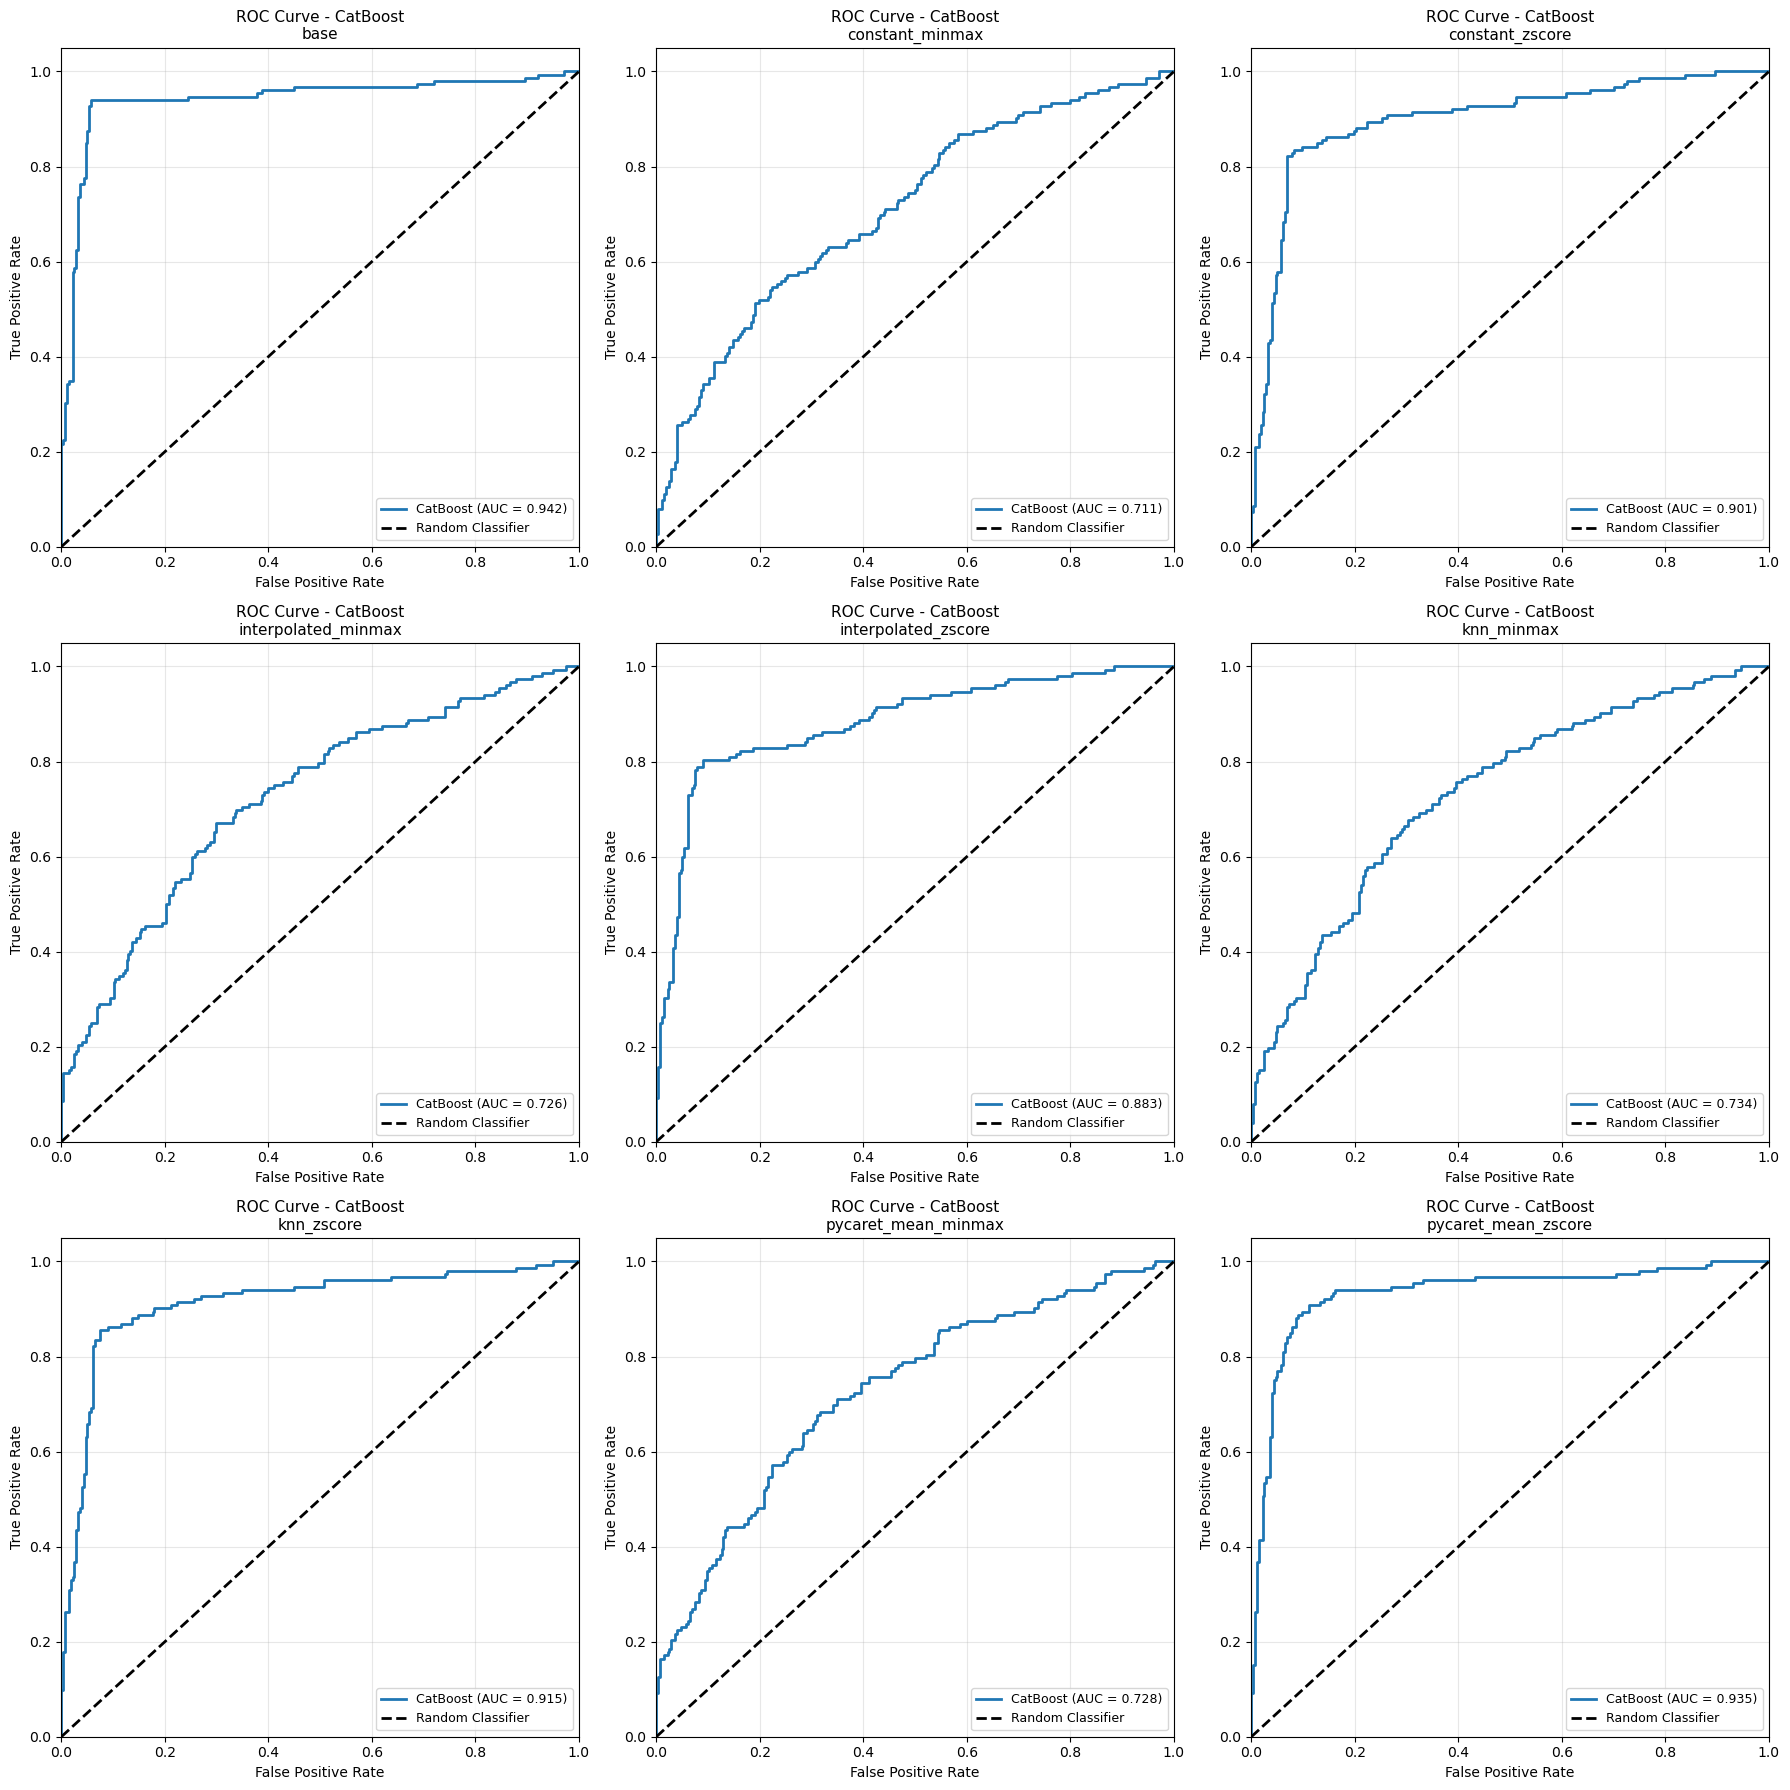

In [26]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt

n_datasets = len(scaled_datasets)
n_cols = 3
n_rows = 3

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
axes = axes.flatten() if n_datasets > 1 else [axes]

for idx, (dataset_name, df) in enumerate(scaled_datasets.items()):
    target = 'Diagnosis'
    X = df.drop(columns=[target])
    y = df[target].astype(int)
    
    X_train, X_val, X_test, y_train, y_val, y_test = stratified_train_val_test_split(
        X, y, test_size=0.2, val_size=0.1, random_state=42
    )
    
    # Get CatBoost model from results
    catboost_model = all_results[dataset_name]['CatBoost']['model']
    
    # Get probability predictions for the positive class
    y_test_proba = catboost_model.predict_proba(X_test)[:, 1]
    
    ax = axes[idx]
    
    # Compute ROC curve and AUC
    fpr, tpr, _ = roc_curve(y_test, y_test_proba)
    roc_auc = auc(fpr, tpr)
    
    ax.plot(fpr, tpr, lw=2, label=f'CatBoost (AUC = {roc_auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
    
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=10)
    ax.set_ylabel('True Positive Rate', fontsize=10)
    ax.set_title(f'ROC Curve - CatBoost\n{dataset_name}', fontsize=11)
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('catboost_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()


### Print AUC scores summary

In [28]:
print(f"\n{'='*70}")
print("CatBoost - AUC Scores Summary")
print(f"{'='*70}")
for dataset_name, df in scaled_datasets.items():
    target = 'Diagnosis'
    X = df.drop(columns=[target])
    y = df[target].astype(int)
    
    X_train, X_val, X_test, y_train, y_val, y_test = stratified_train_val_test_split(
        X, y, test_size=0.2, val_size=0.1, random_state=42
    )
    
    catboost_model = all_results[dataset_name]['CatBoost']['model']
    y_test_proba = catboost_model.predict_proba(X_test)[:, 1]
    
    auc_score = roc_auc_score(y_test, y_test_proba)
    print(f"{dataset_name:>25}:  AUC = {auc_score:.4f}")


CatBoost - AUC Scores Summary
                     base:  AUC = 0.9420
          constant_minmax:  AUC = 0.7110
          constant_zscore:  AUC = 0.9007
      interpolated_minmax:  AUC = 0.7257
      interpolated_zscore:  AUC = 0.8834
               knn_minmax:  AUC = 0.7339
               knn_zscore:  AUC = 0.9148
      pycaret_mean_minmax:  AUC = 0.7280
      pycaret_mean_zscore:  AUC = 0.9347


CatBoost achieves very good AUC scores, indicating strong ability to distingush each class. 

The ROC curves show consistent performance regardless of preprocessing method.

## Confusion matrix

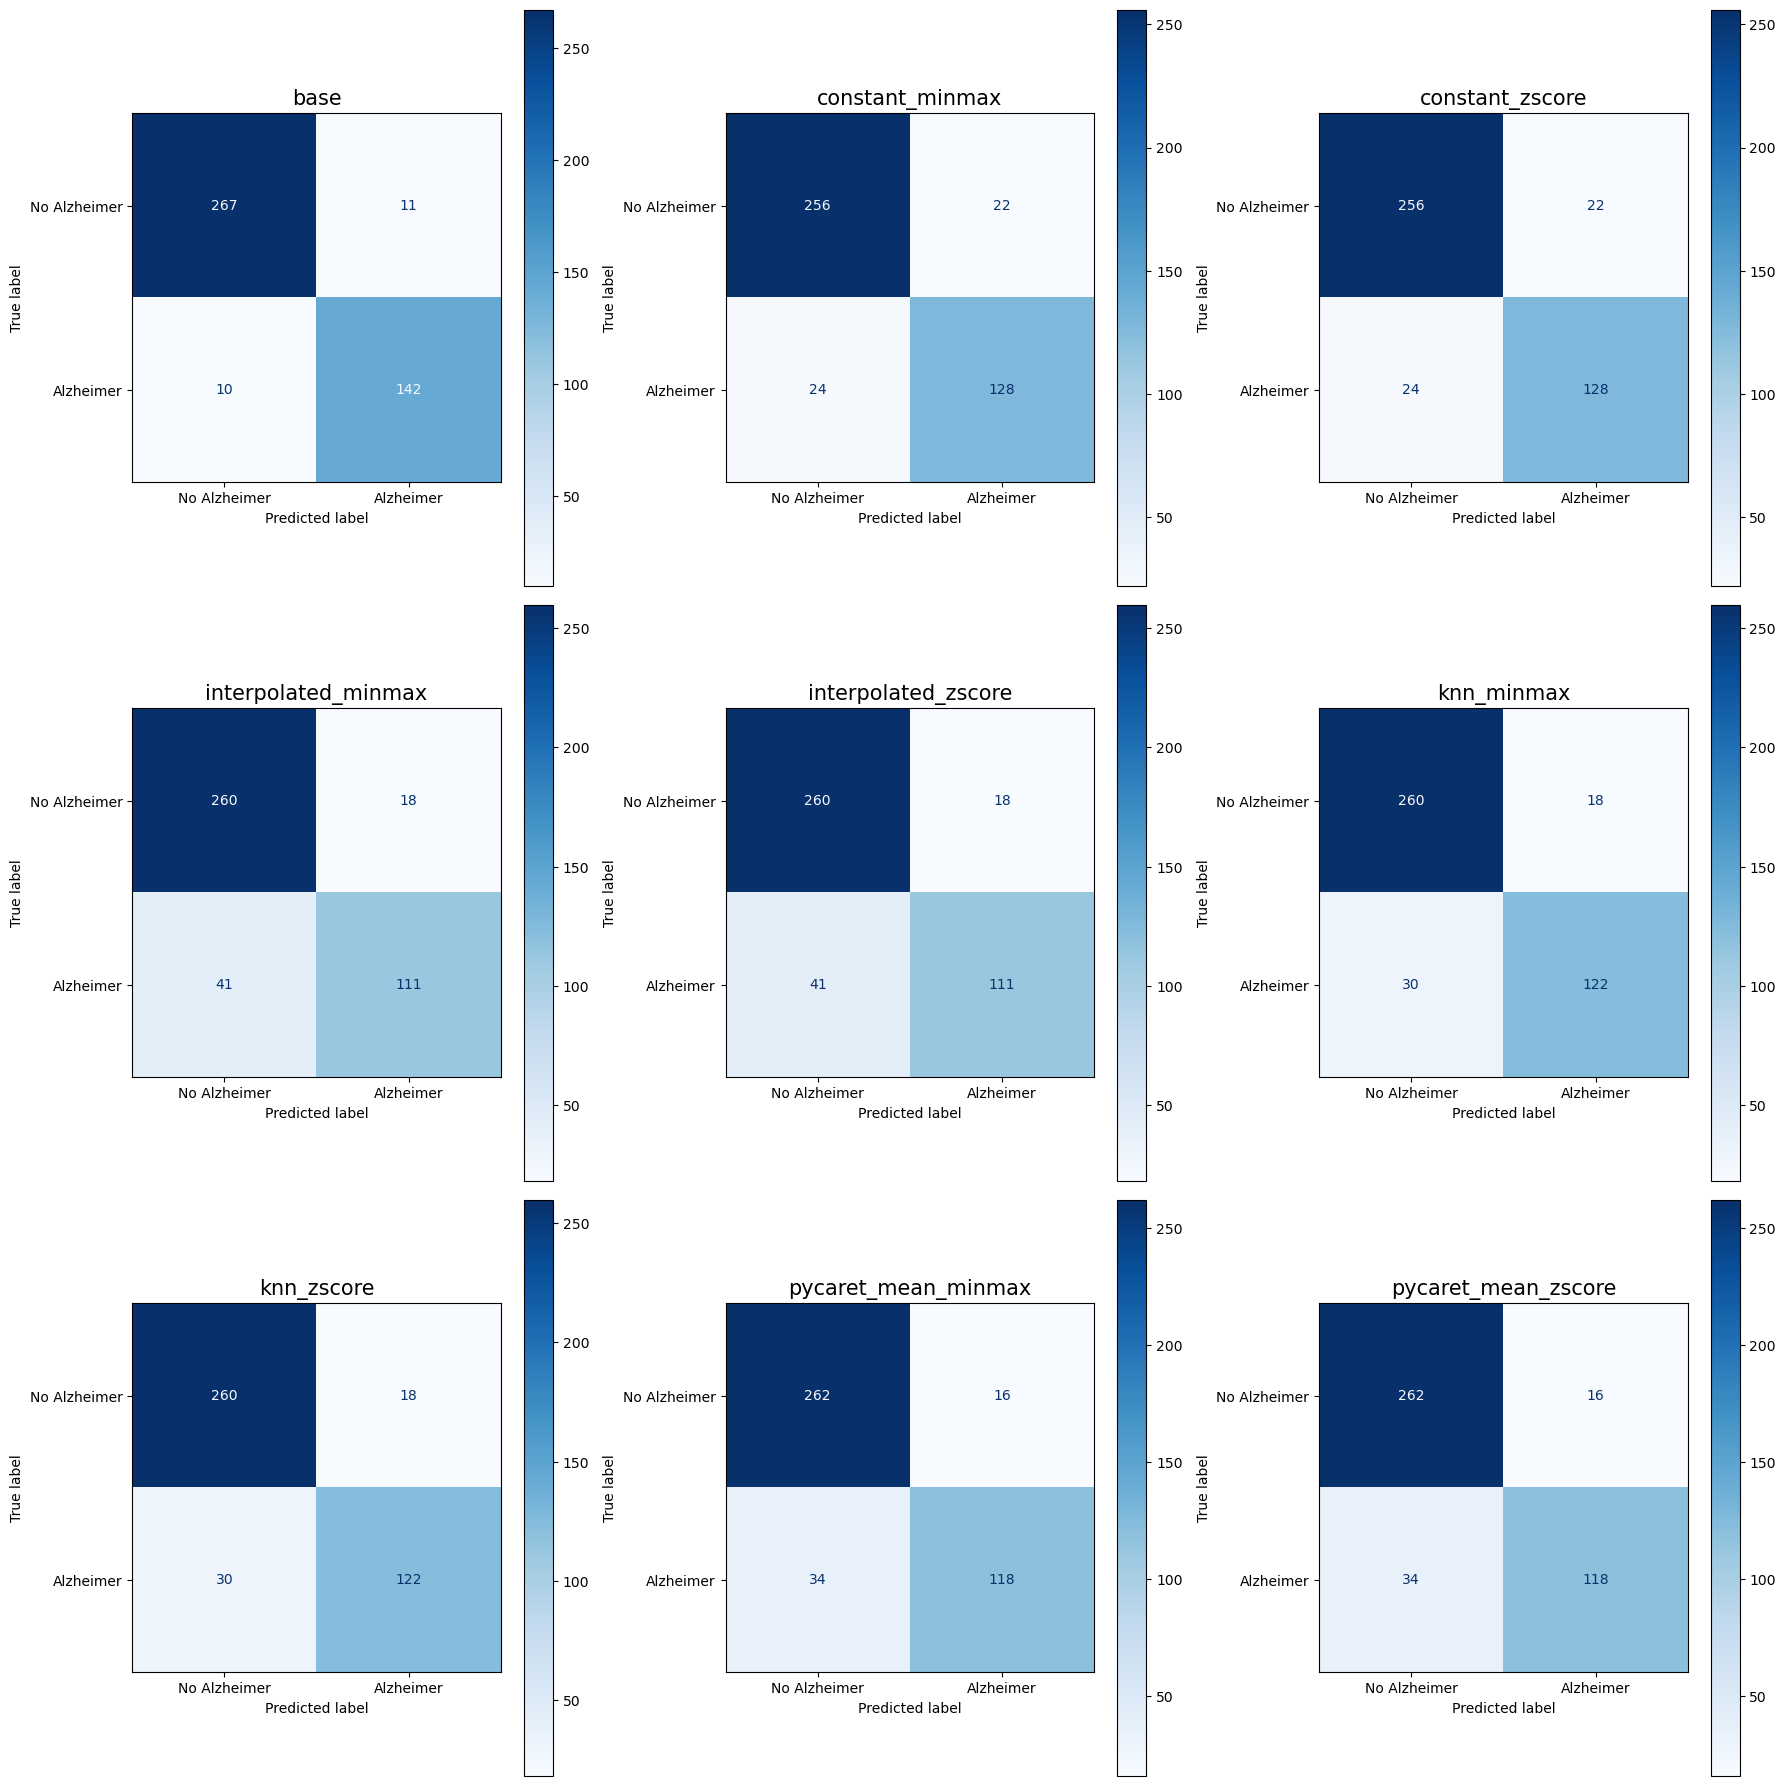

In [35]:
from tkinter import font
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Plot confusion matrices for CatBoost model
n_datasets = len(scaled_datasets)
n_cols = 3
n_rows = 3

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
axes = axes.flatten() if n_datasets > 1 else [axes]

for idx, (dataset_name, df) in enumerate(scaled_datasets.items()):
    target = 'Diagnosis'
    X = df.drop(columns=[target])
    y = df[target].astype(int)
    
    X_train, X_val, X_test, y_train, y_val, y_test = stratified_train_val_test_split(
        X, y, test_size=0.2, val_size=0.1, random_state=42
    )
    
    # Get CatBoost predictions
    y_test_pred = all_results[dataset_name]['CatBoost']['y_test_pred']
    
    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_test_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Alzheimer', 'Alzheimer'])
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=True)
    axes[idx].set_title(f'{dataset_name}', fontsize=15)
    axes[idx].grid(False)

plt.tight_layout()
plt.savefig('catboost_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

### Print confusion matrix statistics

In [31]:
print(f"\n{'='*70}")
print("CatBoost - Confusion Matrix Statistics")
print(f"{'='*70}")
for dataset_name, df in scaled_datasets.items():
    target = 'Diagnosis'
    X = df.drop(columns=[target])
    y = df[target].astype(int)
    
    X_train, X_val, X_test, y_train, y_val, y_test = stratified_train_val_test_split(
        X, y, test_size=0.2, val_size=0.1, random_state=42
    )
    
    y_test_pred = all_results[dataset_name]['CatBoost']['y_test_pred']
    cm = confusion_matrix(y_test, y_test_pred)
    
    tn, fp, fn, tp = cm.ravel()
    
    print(f"\n{dataset_name}:")
    print(f"  True Negatives:  {tn:4d}  |  False Positives: {fp:4d}")
    print(f"  False Negatives: {fn:4d}  |  True Positives:  {tp:4d}")
    print(f"  Sensitivity (Recall): {tp/(tp+fn):.4f}")
    print(f"  Specificity:          {tn/(tn+fp):.4f}")


CatBoost - Confusion Matrix Statistics

base:
  True Negatives:   267  |  False Positives:   11
  False Negatives:   10  |  True Positives:   142
  Sensitivity (Recall): 0.9342
  Specificity:          0.9604

constant_minmax:
  True Negatives:   256  |  False Positives:   22
  False Negatives:   24  |  True Positives:   128
  Sensitivity (Recall): 0.8421
  Specificity:          0.9209

constant_zscore:
  True Negatives:   256  |  False Positives:   22
  False Negatives:   24  |  True Positives:   128
  Sensitivity (Recall): 0.8421
  Specificity:          0.9209

interpolated_minmax:
  True Negatives:   260  |  False Positives:   18
  False Negatives:   41  |  True Positives:   111
  Sensitivity (Recall): 0.7303
  Specificity:          0.9353

interpolated_zscore:
  True Negatives:   260  |  False Positives:   18
  False Negatives:   41  |  True Positives:   111
  Sensitivity (Recall): 0.7303
  Specificity:          0.9353

knn_minmax:
  True Negatives:   260  |  False Positives:   18
